In [1]:
import google.auth
import numpy as np
import pandas as pd
import geopandas as gpd
from calitp_data_analysis import geography_utils
from calitp_data_analysis.sql import to_snakecase
from shared_utils import arcgis_query

In [2]:

import re
import pyarrow.parquet as pq
import gcsfs

In [3]:

import gc
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union


In [4]:
from calitp_data_analysis import get_fs
fs = get_fs()

In [5]:

import os
from typing import List, Optional, Union
import pyarrow.dataset as ds
from google.cloud import storage

In [6]:
import google.auth
import pandas_gbq

credentials, project = google.auth.default()
from functools import cache

from calitp_data_analysis.gcs_pandas import GCSPandas
from calitp_data_analysis.gcs_geopandas import GCSGeoPandas
from calitp_data_analysis.sql import to_snakecase

In [7]:
from typing import List

In [8]:
import geopandas as gpd
import pandas as pd

In [9]:
from functools import cache

from calitp_data_analysis.gcs_geopandas import GCSGeoPandas

@cache
def gcs_geopandas():
    return GCSGeoPandas()

In [10]:
@cache
def gcs_pandas():
    return GCSPandas()

In [11]:
gcsgp = GCSGeoPandas()

In [12]:
pd.options.display.max_columns = 100
pd.options.display.float_format = "{:.2f}".format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Load Census Blocks

In [13]:
census_block_url = "gs://calitp-analytics-data/data-analyses/equity_index/unbuffered_censusblocks_2020/combined_unbufferd_ca_2020.parquet"

In [14]:
census_df = to_snakecase(gcsgp.read_parquet(
   census_block_url)).to_crs(geography_utils.CA_NAD83Albers_m )

In [15]:
census_df.shape

(519723, 19)

In [16]:
stc_only = census_df.loc[census_df.countyfp20 == "085"]

In [17]:
stc_only.shape

(18178, 19)

In [18]:
# stc_only.plot()

# Load HPMS

In [19]:


hpms_url = "gs://calitp-analytics-data/data-analyses/equity_index/HPMS21_Main_SUCU.parquet"



In [20]:
 hpm_df = to_snakecase(gcsgp.read_parquet(
   hpms_url)).to_crs(geography_utils.CA_NAD83Albers_m )

# Script to join Census Blocks to HPM and find the weighted AADT. 


In [ ]:

def intersect_hpm_census_streaming(
    hpm_gdf: gpd.GeoDataFrame,
    census_gdf: gpd.GeoDataFrame,
    buffer_m: int,
    out_path: str,
    batch_size: int = 10000,
    target_crs: str = "EPSG:3310",  # CA Albers; change if your project uses another CRS
    simplify_tolerance: float | None = None,  # e.g., 0.5–2.0 meters if you want vertex reduction
) -> pd.DataFrame:
    """
    Memory-safe EQI traffic overlay:
    - project to area-safe CRS
    - buffer with lower resolution
    - prefilter with sjoin
    - clip only candidates
    - union geometry per unique_id + max AADT
    - compute area & weighted score
    - aggregate by geoid20
    - stream in batches and write partials
    """

    # 0) Project to target CRS (area-safe)
    hpm_gdf = hpm_gdf.to_crs(target_crs)[["routeid", "aadt", "geometry"]].copy()
    census_gdf = census_gdf.to_crs(target_crs)[["geoid20", "geometry"]].copy()

    # 1) Buffer the HPMS lines with *lower resolution*; optional simplify
    #    Resolution reduces circular arc vertices (default 16). 
    hpm_gdf["geometry"] = hpm_gdf.geometry.buffer(buffer_m, resolution=8)
    if simplify_tolerance is not None:
        # Drop high-frequency vertices produced by buffer; preserves topology
        hpm_gdf["geometry"] = hpm_gdf.geometry.simplify(simplify_tolerance, preserve_topology=True)

    # Pre-allocate partial outputs
    partial_scores = []

    # 2) Stream in batches to bound peak memory
    for i in range(0, len(hpm_gdf), batch_size):
        batch = hpm_gdf.iloc[i:i+batch_size].copy()

        # 3) Candidate pairs via spatial join (fast, keeps original left geom)
        #    predicate="intersects" avoids computing expensive overlay for non-candidates
        cand = gpd.sjoin(batch, census_gdf, predicate="intersects", how="inner")

        if cand.empty:
            del batch, cand
            gc.collect()
            continue

        # 4) Compute exact intersection geometry only for candidates
        #    We clip the buffered road to the block it overlaps
        #    Using index_right created by sjoin to fetch the block geometry quickly
        block_geom = census_gdf.loc[cand.index_right, "geometry"].values
        cand["geometry"] = [
            geom.intersection(block_geom[idx])
            for idx, geom in enumerate(cand.geometry.values)
        ]
        cand = cand.drop(columns=["index_right"])  # no longer needed

        # 5) Build unique_id = RouteID + "____" + GEOID (matches R)
        cand["unique_id"] = cand["routeid"].astype(str) + "____" + cand["geoid20"].astype(str)

        # 6) Dissolve by unique_id → union geometry + max(AADT) (matches R fsummarise)
        dissolved = cand.dissolve(by="unique_id", aggfunc={"aadt": "max"}).reset_index()

        # Optional geometry fix if needed:
        dissolved["geometry"] = dissolved.geometry.buffer(0)

        # 7) Area + weighting (use union area, not fragment area)
        dissolved["area"] = dissolved.geometry.area
        dissolved["weighted_aadt"] = dissolved["aadt"] * dissolved["area"]

        # 8) Recover block ID from unique_id and aggregate to block
        dissolved["geoid20"] = dissolved["unique_id"].str.split("____", n=1).str[1]
        part = dissolved.groupby("geoid20", as_index=False)["weighted_aadt"].sum()

        partial_scores.append(part)

        # Free big objects early
        del batch, cand, dissolved, part
        gc.collect()

    # 9) Combine partials → final block score, name column per buffer
    if not partial_scores:
        final = pd.DataFrame(columns=["geoid20", f"aadt_{buffer_m}_score"])
    else:
        final = (
            pd.concat(partial_scores, ignore_index=True)
            .groupby("geoid20", as_index=False)["weighted_aadt"].sum()
            .rename(columns={"weighted_aadt": f"aadt_{buffer_m}_score"})
        )

    # 10) Persist and return
    final.to_parquet("./final.parquet")
    fs.put("./final.parquet", f"calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/{out_path}_traffic_proximity_{buffer_m}_overlay.parquet")
    return final


In [ ]:
df = gcs_pandas().read_parquet("gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sept_1_test_traffic_proximity_overlay_final.parquet")

In [ ]:
df.head(1)

In [ ]:
#for buffer in [450,500]:
#   df_50 = intersect_hpm_census_streaming(
 #   hpm_gdf = hpm_df,
  #  census_gdf= stc_only,
  #  buffer_m= buffer,
  #  out_path= "sept_1_test")
  

# Script to load all the parquets from Google Cloud Storage
* Since I ran the function `intersect_hpm_census_streaming` in a loop for each buffer to not explode the Jupyter Hub memory, that generates a bunch of parquet files. 


In [21]:

def load_eqi_traffic_parquets(file_name: str):
    """
    Reads all EQI traffic parquet files from the GCS folder
    and concatenates them together row-wise (stacked).
    """
    sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
    dfs = []

    for size in sizes:
        path = f"{file_name}{size}_overlay.parquet"
        df = gcs_pandas().read_parquet(path)
        dfs.append(df)

    # Merge all dfs on geoid20
    combined = dfs[0]
    for df in dfs[1:]:
        combined = combined.merge(df, on="geoid20", how="outer")

    if "geoid20" not in combined.columns:
        raise ValueError("Column 'geoid20' not found in concatenated data.")

    return combined


In [22]:
# gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sept_1_test_traffic_proximity_50_overlay.parquet

In [23]:
sept1_df = load_eqi_traffic_parquets("gs://calitp-analytics-data/data-analyses/equity_index/trafficy_proximity_metric/sept_1_test_traffic_proximity_")

In [24]:
sept1_df.head(2)

,geoid20,aadt_50_score,aadt_100_score,aadt_150_score,aadt_200_score,aadt_250_score,aadt_300_score,aadt_350_score,aadt_400_score,aadt_450_score,aadt_500_score
0,060855001001000,2196905507.82,6461225808.22,10878526272.09,14649653431.81,17652579170.28,22707009901.41,24216827555.84,25025077791.72,25699523241.27,26390689874.44
1,060855001001001,832298272.21,2210235278.69,3318393125.03,4222296243.87,4963980288.23,5852666358.14,6326466073.97,7421844163.80,8746857321.35,10213022689.80


# Script to calculate bands and final score

In [25]:
def calculate_bands_geography(df:pd.DataFrame, census_gdf:gpd.GeoDataFrame)->gpd.GeoDataFrame:
    df["p_50_m"]  = df["aadt_50_score"]
    df["p_100_m"] = df["aadt_100_score"] - df["aadt_50_score"]
    df["p_150_m"] = df["aadt_150_score"] - df["aadt_100_score"]
    df["p_200_m"] = df["aadt_200_score"] - df["aadt_150_score"]
    df["p_250_m"] = df["aadt_250_score"] - df["aadt_200_score"]
    df["p_300_m"] = df["aadt_300_score"] - df["aadt_250_score"]
    df["p_350_m"] = df["aadt_350_score"] - df["aadt_300_score"]
    df["p_400_m"] = df["aadt_400_score"] - df["aadt_350_score"]
    df["p_450_m"] = df["aadt_450_score"] - df["aadt_400_score"]
    df["p_500_m"] = df["aadt_500_score"] - df["aadt_450_score"]

    weights = {
	        "p_50_m": 1.0,
	        "p_100_m": 0.5,
	        "p_150_m": 0.33,
	        "p_200_m": 0.25,
	        "p_250_m": 0.20,
	        "p_300_m": 0.16,
	        "p_350_m": 0.14,
	        "p_400_m": 0.125,
	        "p_450_m": 0.111,
	        "p_500_m": 0.10,
    }

    for col, w in weights.items():
        df[f"{col}_w"] = df[col] * w

    weighted_cols = [f"{col}_w" for col in weights.keys()]
    df["weighted_aadt_score"] = df[weighted_cols].sum(axis=1)

    df2 = df[["geoid20", "weighted_aadt_score"]].copy().fillna(0)

    df2["traffic_proximity_and_volume_percentile"] = (
	        df2["weighted_aadt_score"].rank(pct=True)
    )

    m1 = pd.merge(census_gdf[["geoid20","county_name", "geometry"]], df2, on = ["geoid20"], how = "left")
    return m1

In [26]:
sept1_scores_df = calculate_bands_geography(sept1_df, stc_only)

In [27]:
sept1_scores_df.head(2)

,geoid20,county_name,geometry,weighted_aadt_score,traffic_proximity_and_volume_percentile
0,060855017001008,Santa Clara,"POLYGON ((-167338.405 -74700.102, -167329.273 -74694.836, -167272.826 -74797.807, -167257.375 -74839.586, -167144.897 -75008.827, -167149.836 -75012.397, -167157.267 -75016.697, -167168.828 -75023.916, -167238.113 -74898.898, -167348.068 -74705.357, -167338.405 -74700.102))",690797629.02,0.68
1,060855109001003,Santa Clara,"POLYGON ((-188547.742 -62769.999, -188520.355 -62735.256, -188511.345 -62723.673, -188502.260 -62712.758, -188475.008 -62680.014, -188465.924 -62669.099, -188449.876 -62682.581, -188437.297 -62693.093, -188421.571 -62701.231, -188404.053 -62708.296, -188396.831 -62709.459, -188387.318 -62710.896, -188377.601 -62711.115, -188367.000 -62711.353, -188362.573 -62711.008, -188349.282 -62709.528, -188333.206 -62702.106, -188320.613 -62692.382, -188315.213 -62688.056, -188307.162 -62683.789, -188290.569 -62673.043, -188287.428 -62670.890, -188271.202 -62656.800, -188257.551 -62639.316, -188252.859 -62627.190, -188251.560 -62624.440, -188247.284 -62615.085, -188240.876 -62605.221, -188231.767 -62612.876, -188238.058 -62660.769, -188276.158 -62716.065, -188451.504 -62813.862, -188463.626 -62857.621, -188513.421 -62815.915, -188526.760 -62803.829, -188538.539 -62793.111, -188556.841 -62781.580, -188547.742 -62769.999))",230079128.27,0.33


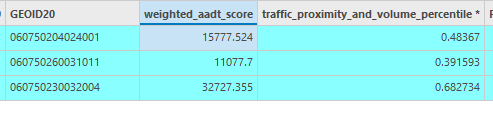

# Compare Henry's Results against Mine

In [28]:
stc_original_url = "gs://calitp-analytics-data/data-analyses/equity_index/original_work/origial_eqi_index.xls"

In [29]:
stc_original_df = to_snakecase(pd.read_excel(stc_original_url))

In [30]:
stc_original_df.sample()

,objectid,countyfp20,geoid20,ur20,housing20,pop20,median_hh_income,rounded_hh_size,local_low_income_threshold,localized_income_screen,state_income_screen,income_screen,crash_score_local,crash_density_local,crash_percentile_local,weighted_aadt_score,traffic_proximity_and_volume_pe,ped_ratio,bike_ratio,transit_ratio_jobs,transit_ratio_pois,screen,tribal_land_indicator,low_income_indicator,demographic_overlay_screen,traffic_exposure_screen,access_to_destinations_screen,tbpp_screen,underserved_community_screen,shape_length,shape_area
14247,14248,85,60855124011025,R,0,0,152500.00,3.00,106000.00,0,0,0,3.92,24.21,0.07,10888.00,0.39,0.02,0.26,0.00,0.00,Non-Screened Blocks,No,No,No,No,No,No,No,0.05,0.00


In [31]:
stc_original_df.countyfp20.nunique()

1

In [32]:
stc_original_df["traffic_proximity_and_volume_percentile"] = (
	        stc_original_df["weighted_aadt_score"].rank(pct=True)
    )

In [33]:
stc_original_df["geoid20"] = stc_original_df["geoid20"].astype(str).str.zfill(15)

In [34]:
merged = pd.merge(sept1_scores_df, stc_original_df,
             on = ["geoid20"],
             suffixes = ("_original", "new"),
             how = "inner")

In [35]:
merged = merged[["geoid20", "traffic_proximity_and_volume_percentilenew", "weighted_aadt_scorenew", "traffic_proximity_and_volume_percentile_original", "weighted_aadt_score_original", "geometry"]]

In [36]:
merged["pct_change"] = (merged.traffic_proximity_and_volume_percentile_original-merged.traffic_proximity_and_volume_percentilenew)/merged.traffic_proximity_and_volume_percentile_original

In [37]:
merged["pct_change"].describe()

count   17497.00
mean       -0.29
std         3.29
min      -363.27
25%        -0.24
50%         0.05
75%         0.31
max         1.00
Name: pct_change, dtype: float64

In [38]:
#merged[["geoid20", "traffic_proximity_and_volume_percentilenew", #"weighted_aadt_scorenew", "traffic_proximity_and_volume_percentile_original", "weighted_aadt_score_original"]].to_csv("./comparison.csv")

In [39]:

merged["traffic_proximity_and_volume_percentilenew"].corr(
        merged["traffic_proximity_and_volume_percentile_original"]
    )


0.6908716037562708

In [40]:

merged["weighted_aadt_scorenew"].corr(
        merged["weighted_aadt_score_original"]
    )


0.5660602711381508

In [41]:
merged["pct_difference"] = merged.traffic_proximity_and_volume_percentilenew - merged.traffic_proximity_and_volume_percentile_original

In [42]:
merged.pct_difference.describe()

count   17497.00
mean       -0.01
std         0.22
min        -0.86
25%        -0.14
50%        -0.02
75%         0.09
max         0.86
Name: pct_difference, dtype: float64

In [43]:
merged[["geoid20", "traffic_proximity_and_volume_percentilenew", "weighted_aadt_scorenew", "traffic_proximity_and_volume_percentile_original", "weighted_aadt_score_original", "pct_difference"]].sample(15)

,geoid20,traffic_proximity_and_volume_percentilenew,weighted_aadt_scorenew,traffic_proximity_and_volume_percentile_original,weighted_aadt_score_original,pct_difference
3972,060855112004008,0.11,5566.11,0.28,191233500.73,-0.17
10583,060855081011009,0.40,21615.86,0.51,397629132.25,-0.11
7448,060855083031011,0.38,20097.03,0.64,613261083.52,-0.26
17739,060855087081006,0.86,88443.74,0.96,4791786441.53,-0.10
14118,060855009012006,0.75,58013.21,0.77,1005941146.03,-0.02
17677,060855067021010,0.24,12080.61,0.24,164228563.65,-0.00
16693,060855001003009,0.72,53040.94,0.59,512498070.90,0.13
17410,060855032202009,0.18,8954.88,0.13,83020343.08,0.05
6940,060855114003002,0.11,5868.55,0.12,80852464.73,-0.01
14218,060855033222009,0.09,4574.73,0.22,144859174.16,-0.13


In [44]:
import matplotlib.pyplot as plt

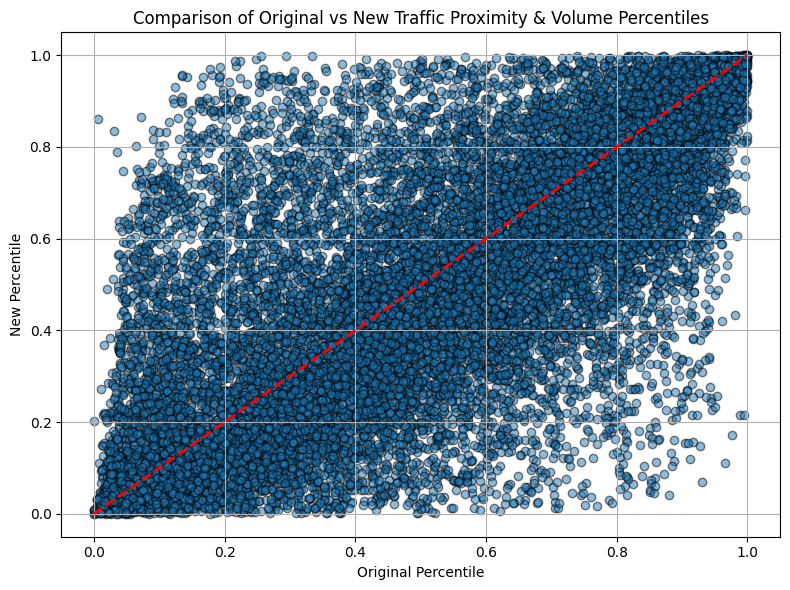

In [45]:

# Replace df with your actual dataframe name
x = merged["traffic_proximity_and_volume_percentile_original"]
y = merged["traffic_proximity_and_volume_percentilenew"]

plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(x, y, alpha=0.5, edgecolor='k')

# 1:1 reference line
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2)

# Labels & title
plt.xlabel("Original Percentile")
plt.ylabel("New Percentile")
plt.title("Comparison of Original vs New Traffic Proximity & Volume Percentiles")

plt.grid(True)
plt.tight_layout()
plt.show()


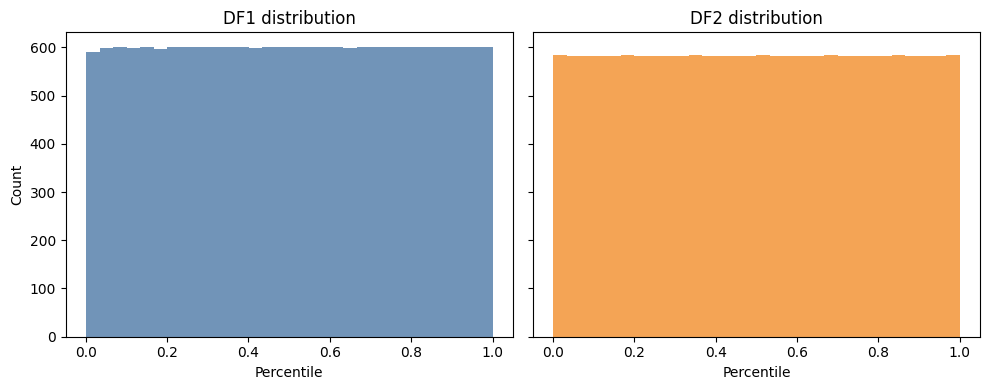

In [46]:



a = merged["traffic_proximity_and_volume_percentile_original"].dropna()
b = merged["traffic_proximity_and_volume_percentilenew"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].hist(a, bins=30, color="#4e79a7", alpha=0.8)
axes[0].set_title("DF1 distribution")
axes[0].set_xlabel("Percentile")
axes[0].set_ylabel("Count")

axes[1].hist(b, bins=30, color="#f28e2b", alpha=0.8)
axes[1].set_title("DF2 distribution")
axes[1].set_xlabel("Percentile")

plt.tight_layout()
plt.show()


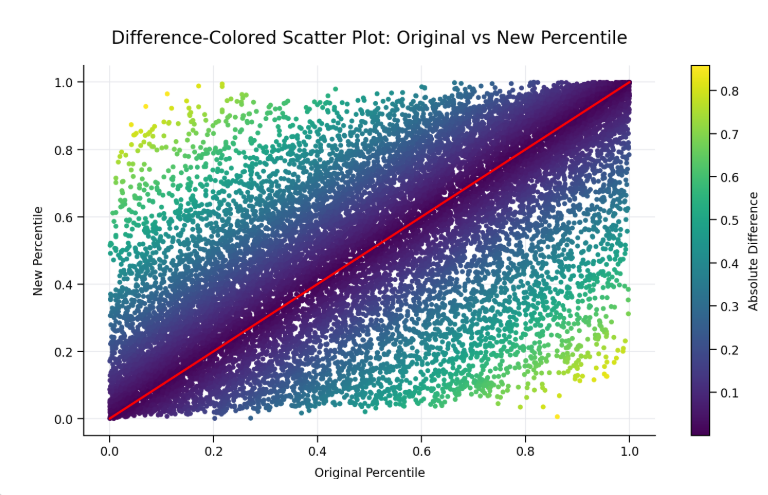